# Wildfire Risk Prediction — Person 5
## Phase 5: Evaluation, Explainability & Visualization

This notebook contains the final deliverables for:

- **Phase 5A:** Evaluation Framework
- **Phase 5B:** SHAP Explainability
- **Phase 5C:** Geospatial Fire Risk Map

**Expected local files/folders**
- `dataset/test.csv`
- `best_model.pkl`
- `regression_model.pkl`
- `kmlfiles/cb_2018_us_county_500k.kml`


## 0. Imports and setup


In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
import folium

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Create output folders
os.makedirs("plots/classification", exist_ok=True)
os.makedirs("plots/regression", exist_ok=True)
os.makedirs("plots/shap", exist_ok=True)
os.makedirs("plots/bonus", exist_ok=True)


/Users/spartan/timeseries/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and models


In [2]:
# Load test data
test_df = pd.read_csv("dataset/test.csv")

# Load trained models
with open("best_model.pkl", "rb") as f:
    clf_model = pickle.load(f)

with open("regression_model.pkl", "rb") as f:
    reg_model = pickle.load(f)

print("Test set shape:", test_df.shape)
print("Classification model:", type(clf_model))
print("Regression model:", type(reg_model))
test_df.head()


Test set shape: (21228, 84)
Classification model: <class 'lightgbm.sklearn.LGBMClassifier'>
Regression model: <class 'xgboost.sklearn.XGBRegressor'>


,date,fire_label,max_frp,max_brightness,fire_count,temp_max,temp_min,humidity,wind_speed,precipitation,...,county_Sonoma,county_Stanislaus,county_Sutter,county_Tehama,county_Trinity,county_Tulare,county_Tuolumne,county_Ventura,county_Yolo,county_Yuba
0,2020-01-01,0.0,0.0,0.0,0.0,13.6045,4.5545,83.52788,11.792404,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2020-01-02,0.0,0.0,0.0,0.0,13.6045,6.9045,80.25659,5.351785,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2020-01-03,0.0,0.0,0.0,0.0,14.9045,2.1045,70.77998,8.759178,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2020-01-04,0.0,0.0,0.0,0.0,12.6045,4.3545,84.26499,11.252519,0.3,...,False,False,False,False,False,False,False,False,False,False
4,2020-01-05,0.0,0.0,0.0,0.0,11.6545,0.8045,83.92218,9.826088,0.0,...,False,False,False,False,False,False,False,False,False,False


## 2. Prepare classification test features

The classifier was trained with:
- `date` removed
- leakage columns removed: `max_frp`, `max_brightness`, `fire_count`
- county dummy names using underscores instead of spaces
- exact column order matching the trained LightGBM model


In [3]:
# Classification target
y_test = test_df["fire_label"]

# Build classification feature matrix
X_test = test_df.drop(
    columns=["fire_label", "date", "max_frp", "max_brightness", "fire_count"],
    errors="ignore"
).copy()

# Match training-time county dummy names
X_test.columns = [
    col.replace(" ", "_") if col.startswith("county_") else col
    for col in X_test.columns
]

# Align exact feature order with the trained LightGBM model
model_features = list(clf_model.booster_.feature_name())
X_test = X_test[model_features]

print("X_test shape:", X_test.shape)
print("Feature alignment correct:", list(X_test.columns) == model_features)


X_test shape: (21228, 79)
Feature alignment correct: True


## 3. Classification evaluation helper


In [4]:
def evaluate_classifier(model, X, y, threshold=0.5, title_suffix="Default Threshold"):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    roc_auc = roc_auc_score(y, probs)
    pr_auc = average_precision_score(y, probs)

    print(f"Threshold: {threshold:.6f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y, preds, zero_division=0))

    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {title_suffix}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    fname = "plots/classification/confusion_matrix_default.png" if threshold == 0.5 else "plots/classification/confusion_matrix_f1_optimal.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    return probs, preds, roc_auc, pr_auc


## 4. Evaluate classifier at default threshold (0.5)


Threshold: 0.500000
ROC-AUC: 0.7623
PR-AUC: 0.2196

Classification Report:

              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94     19704
         1.0       0.24      0.23      0.23      1524

    accuracy                           0.89     21228
   macro avg       0.59      0.59      0.59     21228
weighted avg       0.89      0.89      0.89     21228



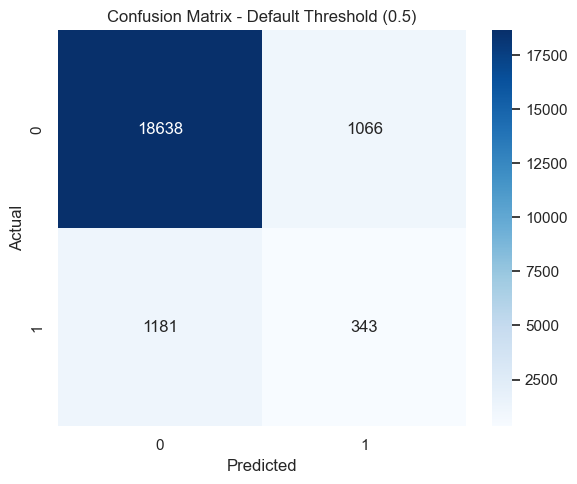

In [5]:
y_probs, y_pred_default, roc_auc_default, pr_auc_default = evaluate_classifier(
    clf_model, X_test, y_test, threshold=0.5, title_suffix="Default Threshold (0.5)"
)


## 5. ROC and Precision-Recall curves


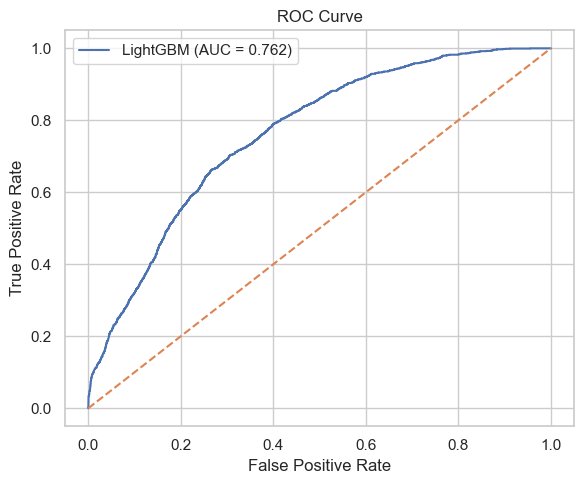

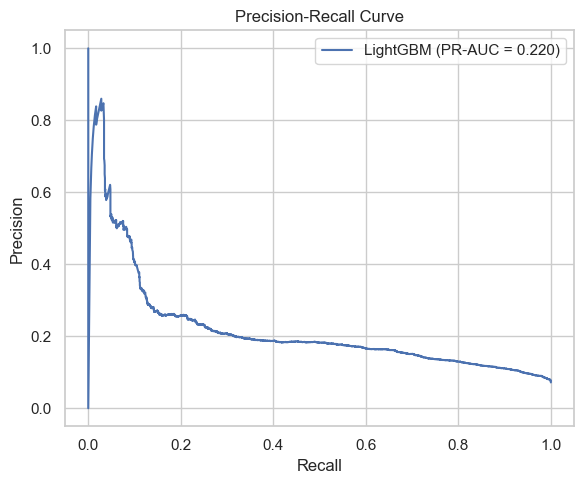

In [6]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LightGBM (AUC = {roc_auc_default:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/classification/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# PR curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"LightGBM (PR-AUC = {pr_auc_default:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/classification/pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Threshold tuning

We compare:
- the threshold that maximizes F1 score
- a very low threshold that reaches high recall, showing the precision trade-off


In [7]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# precision_recall_curve returns one extra precision/recall value
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold (F1):", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1 Score:", f1_scores[best_idx])

# first threshold achieving recall >= 0.80 if available
high_recall_candidates = np.where(recalls[:-1] >= 0.80)[0]
if len(high_recall_candidates) > 0:
    high_recall_idx = high_recall_candidates[0]
    high_recall_threshold = thresholds[high_recall_idx]
    print("\nThreshold for Recall >= 0.80:", high_recall_threshold)
    print("Precision at this threshold:", precisions[high_recall_idx])
else:
    high_recall_threshold = None
    print("\nNo threshold reached recall >= 0.80.")


Best Threshold (F1): 0.4188793965011192
Precision: 0.18278052223006352
Recall: 0.5098425196850394
F1 Score: 0.2690909052058101

Threshold for Recall >= 0.80: 0.0066582849820085365
Precision at this threshold: 0.071791972866026


## 7. Evaluate classifier at the F1-optimal threshold


Threshold: 0.418879
ROC-AUC: 0.7623
PR-AUC: 0.2196

Classification Report:

              precision    recall  f1-score   support

         0.0       0.96      0.82      0.88     19704
         1.0       0.18      0.51      0.27      1524

    accuracy                           0.80     21228
   macro avg       0.57      0.67      0.58     21228
weighted avg       0.90      0.80      0.84     21228



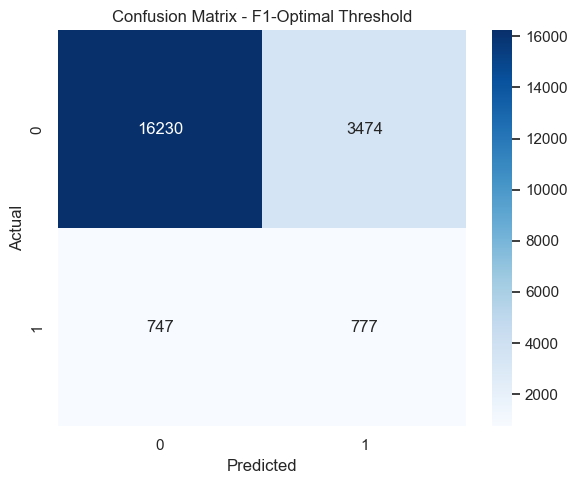

In [8]:
f1_threshold = 0.4188793965011192  # verified during evaluation
y_probs_f1, y_pred_f1, roc_auc_f1, pr_auc_f1 = evaluate_classifier(
    clf_model, X_test, y_test, threshold=f1_threshold, title_suffix="F1-Optimal Threshold"
)


## 8. Threshold trade-off plot (bonus visualization)


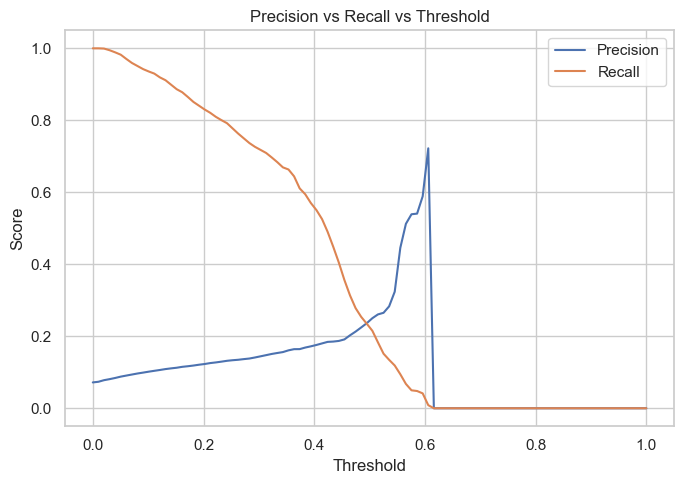

In [9]:
threshold_grid = np.linspace(0, 1, 100)
prec_list = []
rec_list = []

for t in threshold_grid:
    preds_t = (y_probs >= t).astype(int)
    tp = ((preds_t == 1) & (y_test == 1)).sum()
    fp = ((preds_t == 1) & (y_test == 0)).sum()
    fn = ((preds_t == 0) & (y_test == 1)).sum()

    precision_t = tp / (tp + fp + 1e-8)
    recall_t = tp / (tp + fn + 1e-8)

    prec_list.append(precision_t)
    rec_list.append(recall_t)

plt.figure(figsize=(7, 5))
plt.plot(threshold_grid, prec_list, label="Precision")
plt.plot(threshold_grid, rec_list, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/bonus/threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Regression evaluation (Stage 2: FRP prediction)

The regression model is evaluated only on the subset of test rows where fires actually occurred (`fire_label == 1`).


In [10]:
# Filter to fire days only
reg_test_df = test_df[test_df["fire_label"] == 1].copy()
y_reg_test = reg_test_df["max_frp"]

# For regression, keep max_brightness and fire_count if the trained model expects them.
# Drop only the target and date.
X_reg_test = reg_test_df.drop(
    columns=["fire_label", "date", "max_frp"],
    errors="ignore"
).copy()

# Match training-time county dummy names
X_reg_test.columns = [
    col.replace(" ", "_") if col.startswith("county_") else col
    for col in X_reg_test.columns
]

# Align to the trained regression model if feature names are available
if hasattr(reg_model, "feature_names_in_"):
    reg_features = list(reg_model.feature_names_in_)
    missing_reg = sorted(set(reg_features) - set(X_reg_test.columns))
    extra_reg = sorted(set(X_reg_test.columns) - set(reg_features))

    print("Missing regression features:", missing_reg)
    print("Extra regression features:", extra_reg)

    X_reg_test = X_reg_test[reg_features]
    print("Regression features aligned using feature_names_in_.")
else:
    print("Regression model does not expose feature_names_in_. Proceeding with current columns.")
    print("X_reg_test shape:", X_reg_test.shape)

# Predict FRP
y_reg_pred = reg_model.predict(X_reg_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R^2: {r2:.3f}")


Missing regression features: []
Extra regression features: ['county_Alpine', 'county_Amador', 'county_Butte', 'county_Calaveras', 'county_Colusa', 'county_Contra_Costa', 'county_Del_Norte', 'county_El_Dorado', 'county_Fresno', 'county_Glenn', 'county_Humboldt', 'county_Imperial', 'county_Inyo', 'county_Kern', 'county_Kings', 'county_Lake', 'county_Lassen', 'county_Los_Angeles', 'county_Madera', 'county_Marin', 'county_Mariposa', 'county_Mendocino', 'county_Merced', 'county_Modoc', 'county_Mono', 'county_Monterey', 'county_Napa', 'county_Nevada', 'county_Orange', 'county_Placer', 'county_Plumas', 'county_Riverside', 'county_Sacramento', 'county_San_Benito', 'county_San_Bernardino', 'county_San_Diego', 'county_San_Francisco', 'county_San_Joaquin', 'county_San_Luis_Obispo', 'county_San_Mateo', 'county_Santa_Barbara', 'county_Santa_Clara', 'county_Santa_Cruz', 'county_Shasta', 'county_Sierra', 'county_Siskiyou', 'county_Solano', 'county_Sonoma', 'county_Stanislaus', 'county_Sutter', 'count

## 10. Regression plots


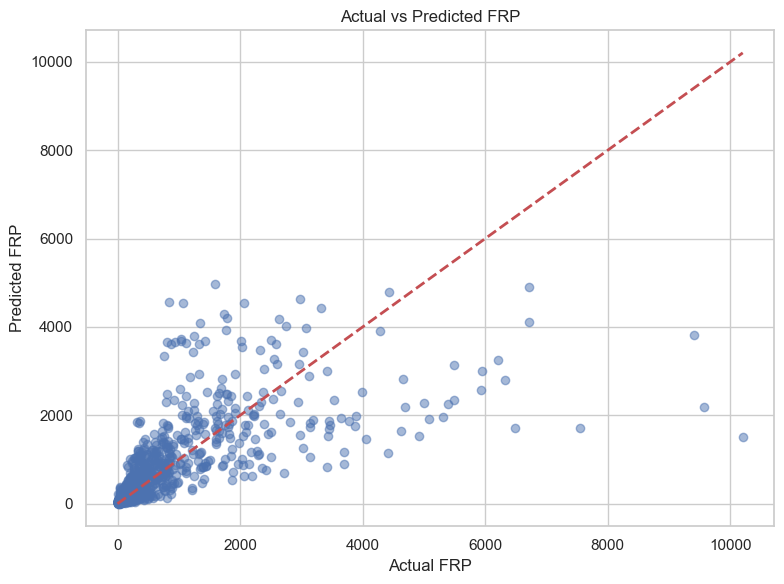

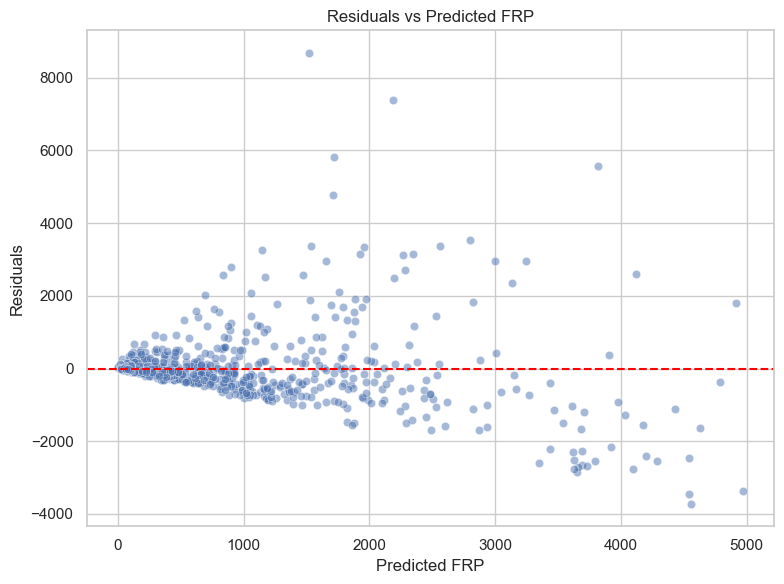

In [11]:
# Predicted vs Actual FRP
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
plt.plot(
    [y_reg_test.min(), y_reg_test.max()],
    [y_reg_test.min(), y_reg_test.max()],
    "r--",
    lw=2
)
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")
plt.title("Actual vs Predicted FRP")
plt.tight_layout()
plt.savefig("plots/regression/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

# Residual plot (without lowess to avoid extra dependency)
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_reg_pred, y=residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted FRP")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted FRP")
plt.tight_layout()
plt.savefig("plots/regression/residuals.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. SHAP explainability setup


In [12]:
sample_size = min(5000, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(clf_model)
shap_values = explainer.shap_values(X_test_sample)

print("Type of shap_values:", type(shap_values))
print("X_test_sample shape:", X_test_sample.shape)

# Normalize to a single 2D array for binary classification when needed
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_plot = shap_values


Type of shap_values: <class 'numpy.ndarray'>
X_test_sample shape: (5000, 79)


## 12. SHAP summary and bar plots


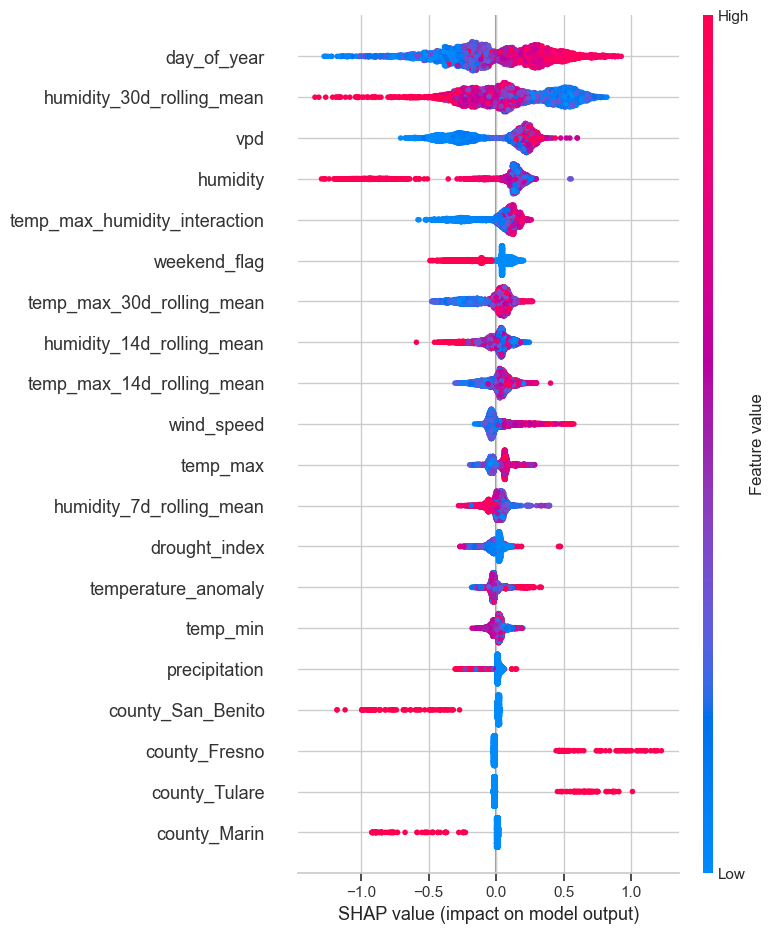

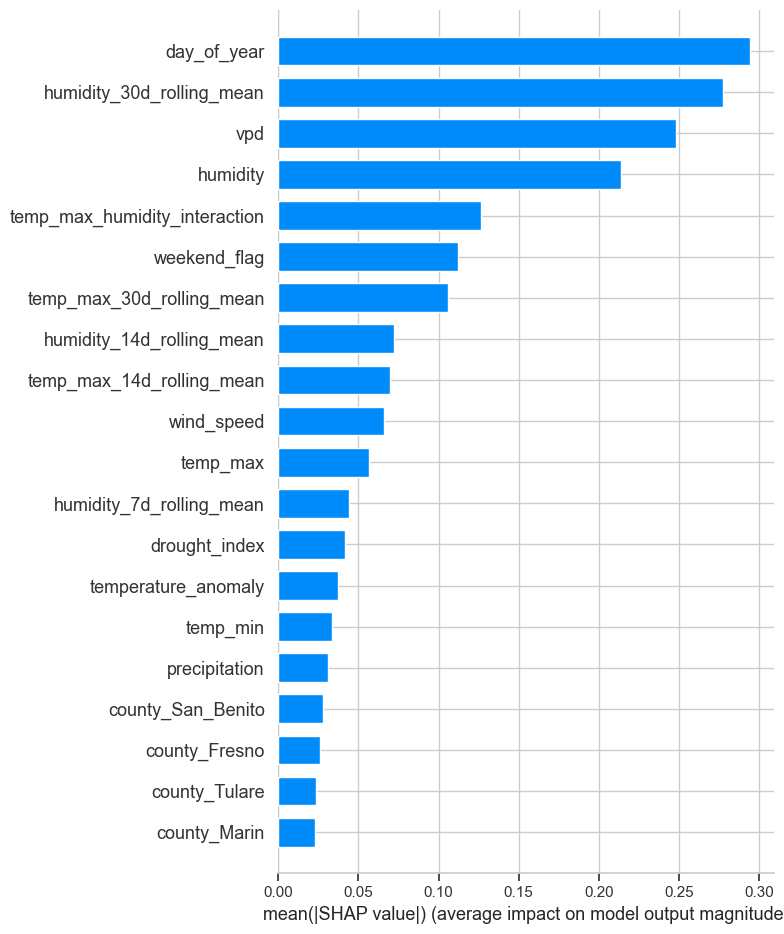

In [13]:
plt.figure()
shap.summary_plot(shap_values_plot, X_test_sample, show=False)
plt.savefig("plots/shap/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
shap.summary_plot(shap_values_plot, X_test_sample, plot_type="bar", show=False)
plt.savefig("plots/shap/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. SHAP dependence plots
Required features:
- `drought_index`
- `vpd`
- `temp_max`


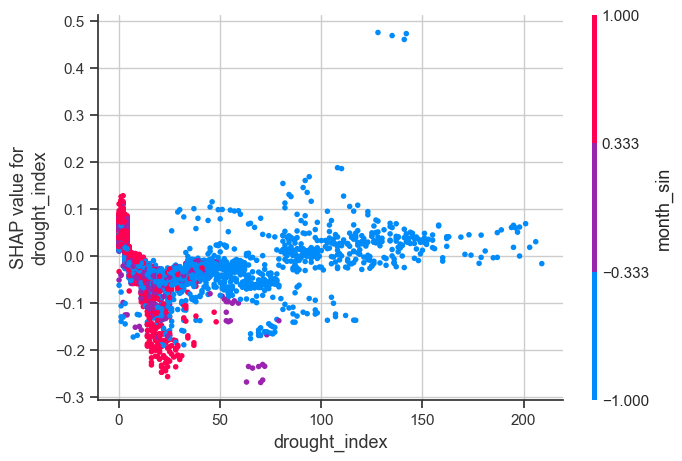

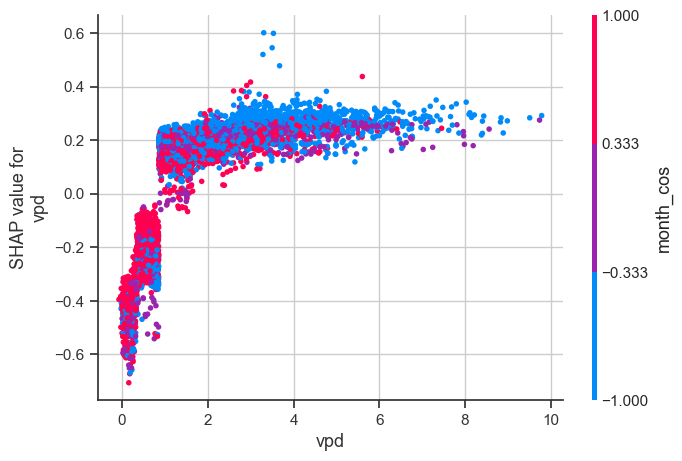

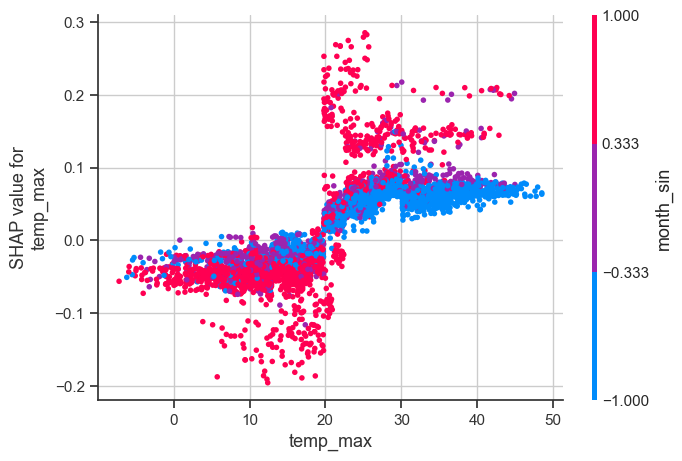

In [14]:
for feature_name, outname in [
    ("drought_index", "plots/shap/shap_drought_index.png"),
    ("vpd", "plots/shap/shap_vpd.png"),
    ("temp_max", "plots/shap/shap_temp_max.png"),
]:
    shap.dependence_plot(feature_name, shap_values_plot, X_test_sample, show=False)
    plt.savefig(outname, dpi=150, bbox_inches="tight")
    plt.show()


## 14. SHAP force plots for high-risk cases

These plots explain a few individual examples with the highest predicted wildfire probability.


In [15]:
sample_probs = clf_model.predict_proba(X_test_sample)[:, 1]
top_idx = np.argsort(sample_probs)[-3:]

print("Top sample indices:", top_idx)
print("Top probabilities:", sample_probs[top_idx])

shap.initjs()

expected_value = explainer.expected_value
if isinstance(expected_value, list) or isinstance(expected_value, np.ndarray):
    if np.array(expected_value).ndim > 0 and len(np.array(expected_value)) > 1:
        expected_value = np.array(expected_value)[1]
    else:
        expected_value = np.array(expected_value).reshape(-1)[0]

for idx in top_idx:
    display(
        shap.force_plot(
            expected_value,
            shap_values_plot[idx],
            X_test_sample.iloc[idx]
        )
    )


Top sample indices: [2063 1689 2983]
Top probabilities: [0.60721535 0.60721535 0.60743541]


## 15. Fire risk map by county

This section creates an interactive California county map colored by average predicted wildfire risk on the test set.


In [16]:
# Load county boundaries from KML
gdf = gpd.read_file("kmlfiles/cb_2018_us_county_500k.kml", driver="KML")

# Keep California only
ca_gdf = gdf[gdf["STATEFP"] == "06"].copy()
ca_gdf["county_name"] = ca_gdf["Name"]

print("California counties in map file:", ca_gdf.shape[0])


California counties in map file: 58


In [17]:
# Rebuild map prediction dataframe from original test set
df_map = pd.read_csv("dataset/test.csv")

X_map = df_map.drop(
    columns=["fire_label", "date", "max_frp", "max_brightness", "fire_count"],
    errors="ignore"
).copy()

X_map.columns = [
    col.replace(" ", "_") if col.startswith("county_") else col
    for col in X_map.columns
]

X_map = X_map[clf_model.booster_.feature_name()]
df_map["predicted_fire_risk"] = clf_model.predict_proba(X_map)[:, 1]

county_cols = [c for c in df_map.columns if c.startswith("county_")]

def get_county_from_row(row):
    active = [c for c in county_cols if row[c] == 1]
    if len(active) == 0:
        return "Alameda"   # baseline county from drop-first encoding
    return active[0].replace("county_", "").replace("_", " ")

df_map["county_name"] = df_map.apply(get_county_from_row, axis=1)

df_county_risk = (
    df_map.groupby("county_name", as_index=False)["predicted_fire_risk"]
    .mean()
    .sort_values("predicted_fire_risk", ascending=False)
)

df_county_risk.head(10)


,county_name,predicted_fire_risk
9,Fresno,0.414169
12,Imperial,0.393623
53,Tulare,0.384388
14,Kern,0.350548
35,San Bernardino,0.328444
5,Colusa,0.324958
19,Madera,0.318646
23,Merced,0.315879
26,Monterey,0.305876
49,Stanislaus,0.302233


In [18]:
# Merge county risk with county boundaries
map_df = ca_gdf.merge(df_county_risk, on="county_name", how="left")

print("Missing counties after merge:", map_df["predicted_fire_risk"].isna().sum())
map_df[["county_name", "predicted_fire_risk"]].head()


Missing counties after merge: 0


,county_name,predicted_fire_risk
0,Alameda,0.139182
1,Alpine,0.178658
2,Amador,0.135411
3,Butte,0.285746
4,Calaveras,0.198594


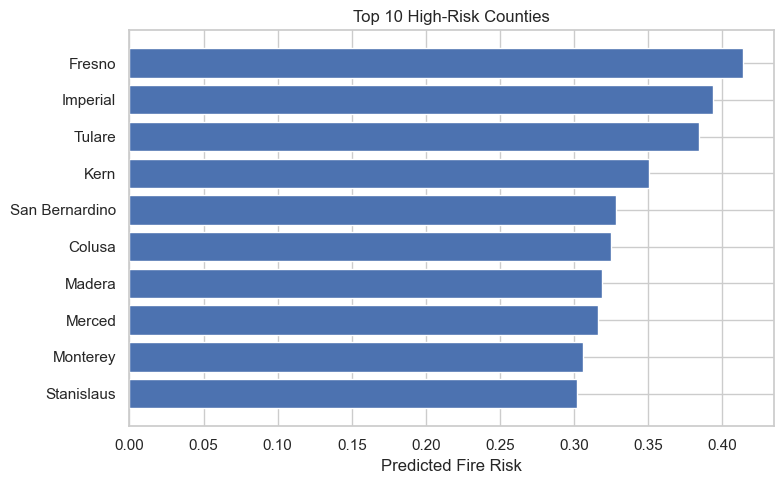

In [19]:
# Optional supporting chart: top 10 high-risk counties
top10 = df_county_risk.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10["county_name"], top10["predicted_fire_risk"])
plt.gca().invert_yaxis()
plt.xlabel("Predicted Fire Risk")
plt.title("Top 10 High-Risk Counties")
plt.tight_layout()
plt.savefig("plots/bonus/top10_counties.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
# Create and save interactive Folium map
m = folium.Map(location=[37.25, -119.5], zoom_start=6, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=map_df.to_json(),
    data=map_df,
    columns=["county_name", "predicted_fire_risk"],
    key_on="feature.properties.county_name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Average Predicted Wildfire Risk (Test Set)"
).add_to(m)

folium.GeoJson(
    map_df,
    style_function=lambda feature: {
        "fillColor": "transparent",
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["county_name", "predicted_fire_risk"],
        aliases=["County:", "Predicted Risk:"],
        localize=True
    )
).add_to(m)

m.save("fire_risk_map.html")
m


## 16. Interpretation notes

### Test evaluation
**ROC-AUC = 0.762, PR-AUC = 0.220**

The LightGBM classifier shows reasonable discrimination on the test set, especially given the strong class imbalance. ROC-AUC indicates the model separates fire and non-fire days moderately well, while the lower PR-AUC reflects the difficulty of predicting rare wildfire events.

### Confusion matrix
At the default threshold of 0.5, the model correctly identifies most non-fire days but misses many true fire days. This means the classifier is conservative and has relatively low recall for the wildfire class.

### Threshold tuning
Lowering the threshold improves recall but sharply reduces precision. The F1-optimal threshold provides a better trade-off than the default threshold, while the very low threshold required for recall near 0.80 leads to too many false positives to be practical.

### SHAP summary plot
The SHAP summary plot shows that **day_of_year, humidity-related rolling averages, VPD, and humidity** are among the most influential features in wildfire risk prediction. Higher atmospheric dryness and seasonal timing push predictions toward higher wildfire risk.

### SHAP bar plot
The SHAP bar plot confirms the global importance ranking of the model’s features. Seasonal and moisture-related variables dominate the predictions, which is consistent with wildfire behavior in California.

### SHAP dependence: drought index
As drought index increases, wildfire risk generally rises. This suggests that longer dry periods contribute to elevated fire probability.

### SHAP dependence: VPD
Higher VPD values are associated with higher wildfire risk. This makes sense because larger vapor pressure deficit indicates drier air and stronger fuel drying conditions.

### SHAP dependence: temp_max
Higher maximum daily temperature tends to increase predicted wildfire risk. Hotter days likely contribute to drier vegetation and more fire-conducive conditions.

### Force plots
For individual high-risk cases, the strongest positive contributors are high temperature, low humidity, high VPD, and late-season timing. These local explanations match the global SHAP patterns and increase trust in the model.

### Fire risk map
The county-level fire risk map shows spatial variation in predicted wildfire probability across California. Counties with hotter, drier, and more fire-prone seasonal conditions tend to have higher average predicted risk.
